In [2]:
import pandas as pd

df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None)
df.columns = ["Date", "Time", "Depth", "Temperature", "Salinity"]
#converting to csv
df.to_csv("E2_CTD_20260507.csv", index=False)


In [3]:
df.head()

,Date,Time,Depth,Temperature,Salinity
0,11/29/2008,06:52,5,28.97,35.21
1,11/29/2008,06:52,6,28.98,35.21
2,11/29/2008,06:52,7,28.99,35.21
3,11/29/2008,06:52,8,28.96,35.21
4,11/29/2008,06:52,9,28.99,35.21


In [4]:
df = pd.read_csv("E2_CTD_20260507.csv")

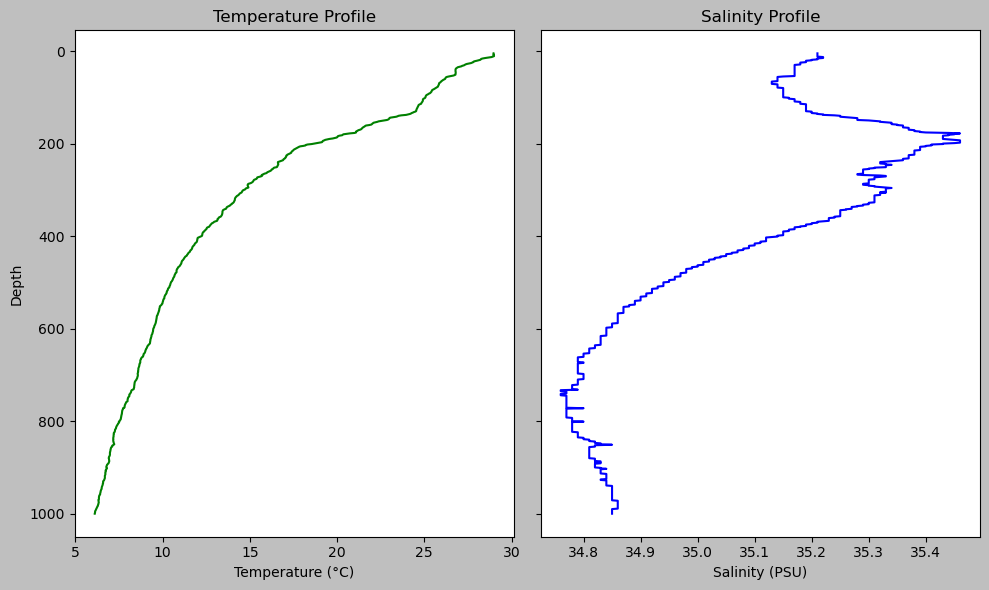

In [7]:
import matplotlib.pyplot as plt
df = pd.read_csv("E2_CTD_20260507.csv")
y= df["Depth"]
temp = df["Temperature"]
sal = df["Salinity"]
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(10, 6))

# Temperature profile
axes[0].plot(temp, y, color= "green")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth")
axes[0].set_title("Temperature Profile")
# Salinity profile
axes[1].plot(sal, y, color="blue")
axes[1].set_xlabel("Salinity (PSU)")
axes[1].set_title("Salinity Profile")

# Invert y-axis (important for ocean depth!)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

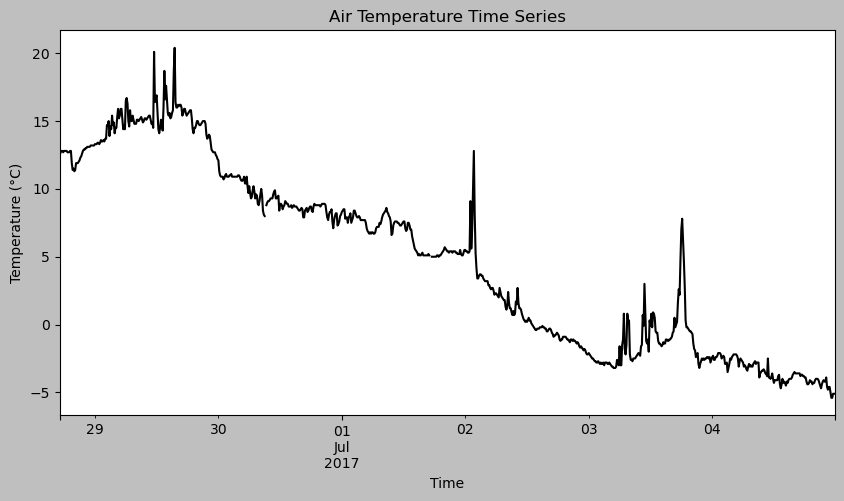

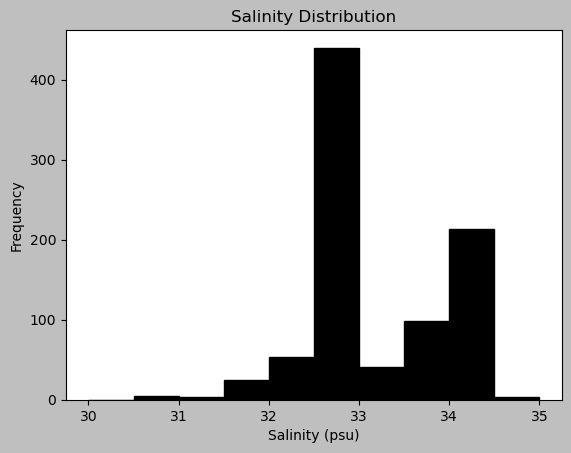

                       Mean   Std Dev        IQR
Temperature (°C)   4.878271  6.692847  11.675000
Salinity (psu)    33.110553  1.140150   1.272575


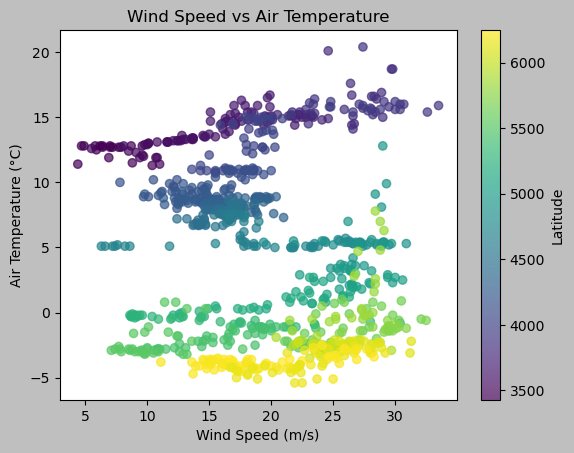

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the CSV file with TIME_SERVER as datetime index
df = pd.read_csv("SAA2_WC_2017_metocean_10min_avg.csv", parse_dates=["TIME_SERVER"], na_values=["NULL"])

# Set TIME_SERVER as index
df.set_index("TIME_SERVER", inplace=True)

# 2. Select data from departure until July 4th (inclusive)
end_date = "2017-07-04"
df_selected = df.loc[:end_date]

# 3. Plot time series of air temperature
plt.style.use("grayscale")
df_selected["AIR_TEMPERATURE"].plot(figsize=(10, 5))
plt.title("Air Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.savefig("temperature_timeseries.png", dpi=300)
plt.show()

# 4. Plot histogram of salinity distribution
plt.hist(df_selected["TSG_SALINITY"].dropna(), bins=np.arange(30, 35.5, 0.5), edgecolor="black")
plt.title("Salinity Distribution")
plt.xlabel("Salinity (psu)")
plt.ylabel("Frequency")
plt.savefig("salinity_histogram.png", dpi=300)
plt.show()

# 5. Calculate statistics for temperature and salinity
stats = pd.DataFrame({
    "Mean": [df_selected["AIR_TEMPERATURE"].mean(), df_selected["TSG_SALINITY"].mean()],
    "Std Dev": [df_selected["AIR_TEMPERATURE"].std(), df_selected["TSG_SALINITY"].std()],
    "IQR": [
        df_selected["AIR_TEMPERATURE"].quantile(0.75) - df_selected["AIR_TEMPERATURE"].quantile(0.25),
        df_selected["TSG_SALINITY"].quantile(0.75) - df_selected["TSG_SALINITY"].quantile(0.25)
    ]
}, index=["Temperature (°C)", "Salinity (psu)"])

print(stats)

# 6. Scatter plot of wind speed vs air temperature, colored by latitude
plt.scatter(df_selected["WIND_SPEED_TRUE"], df_selected["AIR_TEMPERATURE"],
            c=df_selected["LATITUDE"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Latitude")
plt.title("Wind Speed vs Air Temperature")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Air Temperature (°C)")
plt.savefig("wind_temp_scatter.png", dpi=300)
plt.show()